In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\jhana\OneDrive\Desktop\projects\Capstone_2_Semiconductor
['.ipynb_checkpoints', 'Capstone_2_Semiconductor.ipynb', 'secom', 'secom .zip', 'secom.data', 'secom.names', 'secom_labels.data', 'semiconductor_yield_best_model.joblib', 'sensor-data.csv']


# CAPSTONE PROJECT 2
## Semiconductor Manufacturing Process — Yield Prediction

### Project Objective

The objective of this project is to build a machine learning classification system
to predict whether a semiconductor manufacturing process results in Pass or Fail.

The project also investigates whether all sensor features are necessary for
accurate prediction and identifies important sensor features using feature
importance analysis.

### Dataset

- Dataset: SECOM Semiconductor Manufacturing Dataset
- Samples: 1567
- Sensor/process measurements: 590
- Target:
  - -1 → Pass
  - 1 → Fail
- Timestamp: Available for each test point

### Machine Learning Models

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

### Techniques Used

- Data Cleaning
- Missing Value Handling
- Exploratory Data Analysis
- Train-Test Split
- Standardization
- SMOTE
- Cross-Validation
- GridSearchCV
- Feature Importance
- Feature Reduction
- Model Comparison
- Model Saving

In [3]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\jhana\OneDrive\Desktop\projects\Capstone_2_Semiconductor
['.ipynb_checkpoints', 'Capstone_2_Semiconductor.ipynb', 'secom', 'secom .zip', 'secom.data', 'secom.names', 'secom_labels.data', 'semiconductor_yield_best_model.joblib', 'sensor-data.csv']


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [68]:
# 1. Import Libraries

In [4]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Capstone_2_Semiconductor.ipynb', 'secom', 'secom .zip', 'secom.data', 'secom.names', 'secom_labels.data', 'semiconductor_yield_best_model.joblib', 'sensor-data.csv']


In [5]:
X_raw = pd.read_csv("secom.data", sep=r"\s+", header=None)
labels_raw = pd.read_csv("secom_labels.data", sep=r"\s+", header=None)

print("Sensor data shape:", X_raw.shape)
print("Labels data shape:", labels_raw.shape)

Sensor data shape: (1567, 590)
Labels data shape: (1567, 2)


In [6]:
print("First 5 rows of sensor data:")
display(X_raw.head())

First 5 rows of sensor data:


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [7]:
print("First 5 rows of labels:")
display(labels_raw.head())

First 5 rows of labels:


,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [8]:
df = X_raw.copy()

df["target"] = labels_raw.iloc[:, 0]
df["timestamp"] = labels_raw.iloc[:, 1]

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1567, 592)


In [9]:
sensor_columns = [f"sensor_{i}" for i in range(X_raw.shape[1])]

df.columns = sensor_columns + ["target", "timestamp"]

print("Number of columns:", len(df.columns))
display(df.head())

Number of columns: 592


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,target,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,19/07/2008 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,19/07/2008 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,19/07/2008 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,19/07/2008 15:22:00


In [10]:
df.to_csv("sensor-data.csv", index=False)

print("sensor-data.csv created successfully!")

sensor-data.csv created successfully!


In [11]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (1567, 592)

Column names:
['sensor_0', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'sensor_52', 'sensor_53', 'sensor_54', 'sensor_55', 'sensor_56', 'sensor_57', 'sensor_58', 'sensor_59', 'sensor_60', 'sensor_61', 'sensor_62', 'sensor_63', 'sensor_64', 'sensor_65', 'sensor_66', 'sensor_67', 'sensor_68', 'sensor_69', 'sensor_70', 'sensor_71', 'sensor_72', 'sensor_73', 'sens

In [12]:
print(df.dtypes.value_counts())

float64    590
int64        1
str          1
Name: count, dtype: int64


In [13]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sensor_0,1561.0,NaN,NaN,NaN,3014.452896,73.621787,2743.24,2966.26,3011.49,3056.65,3356.35
sensor_1,1560.0,NaN,NaN,NaN,2495.850231,80.407705,2158.75,2452.2475,2499.405,2538.8225,2846.44
sensor_2,1553.0,NaN,NaN,NaN,2200.547318,29.513152,2060.66,2181.0444,2201.0667,2218.0555,2315.2667
sensor_3,1553.0,NaN,NaN,NaN,1396.376627,441.69164,0.0,1081.8758,1285.2144,1591.2235,3715.0417
sensor_4,1553.0,NaN,NaN,NaN,4.197013,56.35554,0.6815,1.0177,1.3168,1.5257,1114.5366
...,...,...,...,...,...,...,...,...,...,...,...
sensor_587,1566.0,NaN,NaN,NaN,0.016475,0.008808,0.0032,0.0106,0.0148,0.0203,0.0799
sensor_588,1566.0,NaN,NaN,NaN,0.005283,0.002867,0.001,0.0033,0.0046,0.0064,0.0286
sensor_589,1566.0,NaN,NaN,NaN,99.670066,93.891919,0.0,44.3686,71.9005,114.7497,737.3048
target,1567.0,NaN,NaN,NaN,-0.867262,0.49801,-1.0,-1.0,-1.0,-1.0,1.0


In [14]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

display(missing_summary.head(20))

,Missing_Count,Missing_Percentage
sensor_292,1429,91.193363
sensor_293,1429,91.193363
sensor_157,1429,91.193363
sensor_158,1429,91.193363
sensor_492,1341,85.577537
sensor_220,1341,85.577537
sensor_85,1341,85.577537
sensor_358,1341,85.577537
sensor_110,1018,64.964901
sensor_517,1018,64.964901


In [15]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 41951


In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
print("Target value counts:")
print(df["target"].value_counts())

Target value counts:
target
-1    1463
 1     104
Name: count, dtype: int64


In [18]:
target_percentage = df["target"].value_counts(normalize=True) * 100

print("Target percentages:")
print(target_percentage)

Target percentages:
target
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


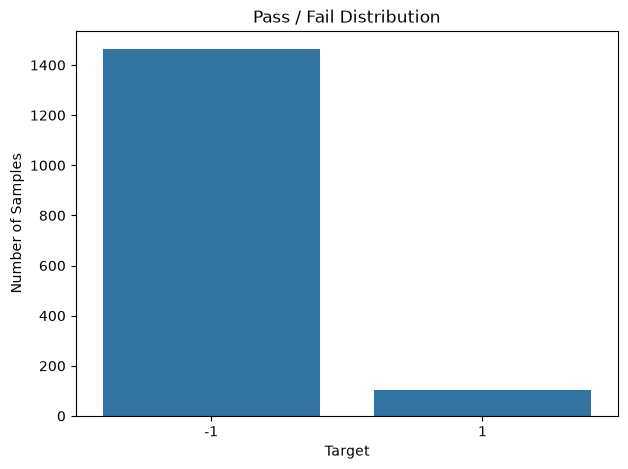

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="target")

plt.title("Pass / Fail Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Samples")

plt.show()

In [20]:
features_with_missing = (df.isnull().sum() > 0).sum()

print("Number of features containing missing values:",
      features_with_missing)

Number of features containing missing values: 538


In [21]:
feature_columns = [col for col in df.columns if col.startswith("sensor_")]

constant_features = []

for col in feature_columns:
    if df[col].nunique(dropna=False) <= 1:
        constant_features.append(col)

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("Constant features:")
    print(constant_features)
    

Number of constant features: 0


In [22]:
df_clean = df.drop(columns=constant_features)

print("Shape after removing constant features:",
      df_clean.shape)


Shape after removing constant features: (1567, 592)


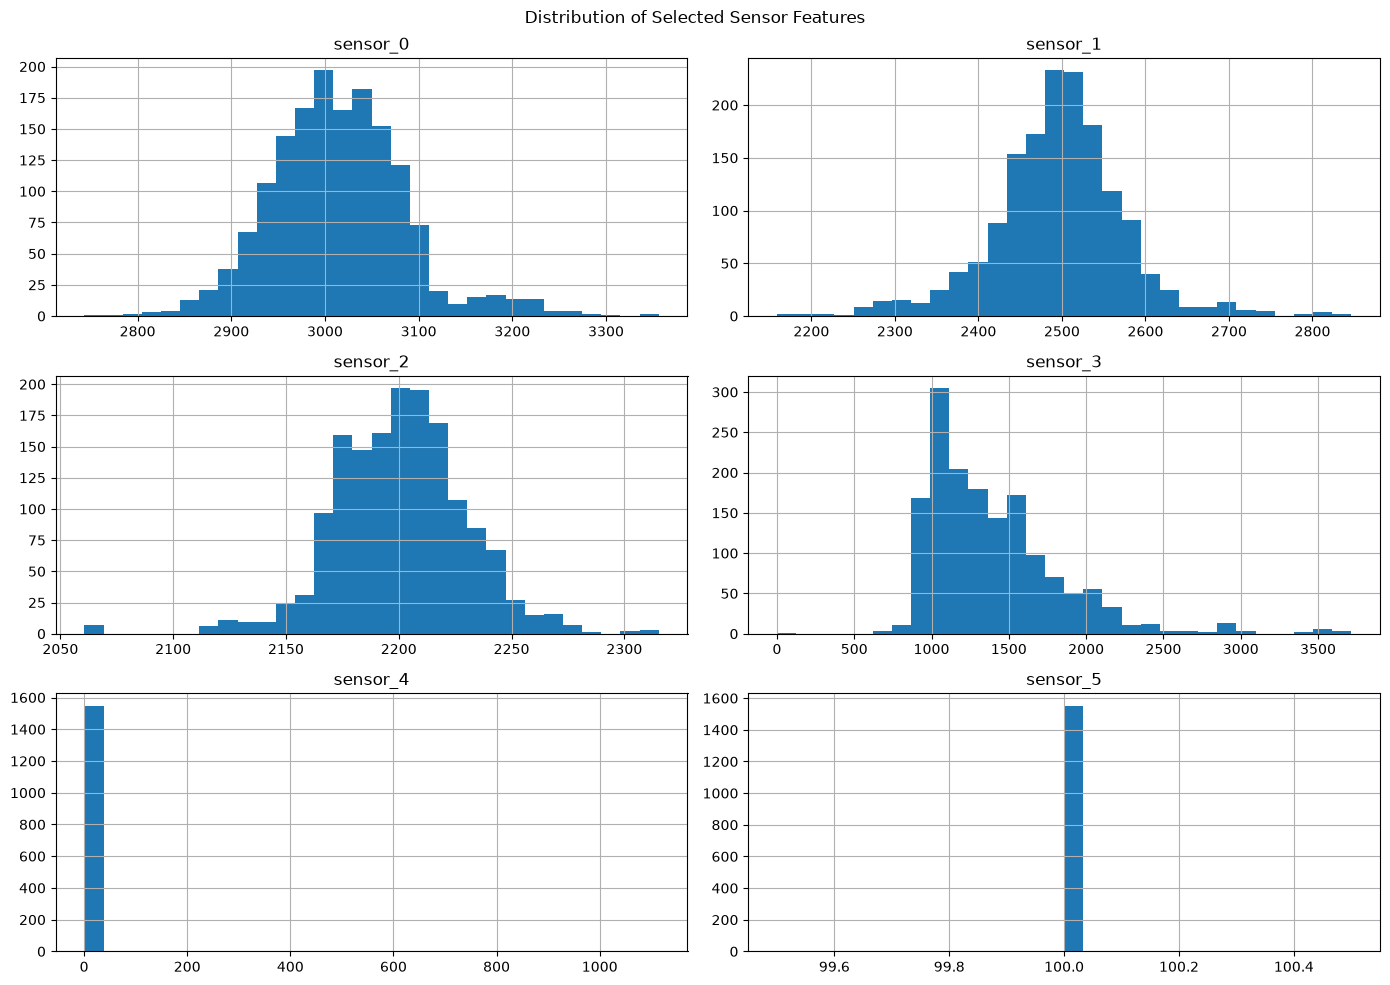

In [23]:
selected_sensors = [
    col for col in df_clean.columns
    if col.startswith("sensor_")
][:6]

df_clean[selected_sensors].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Selected Sensor Features")

plt.tight_layout()
plt.show()

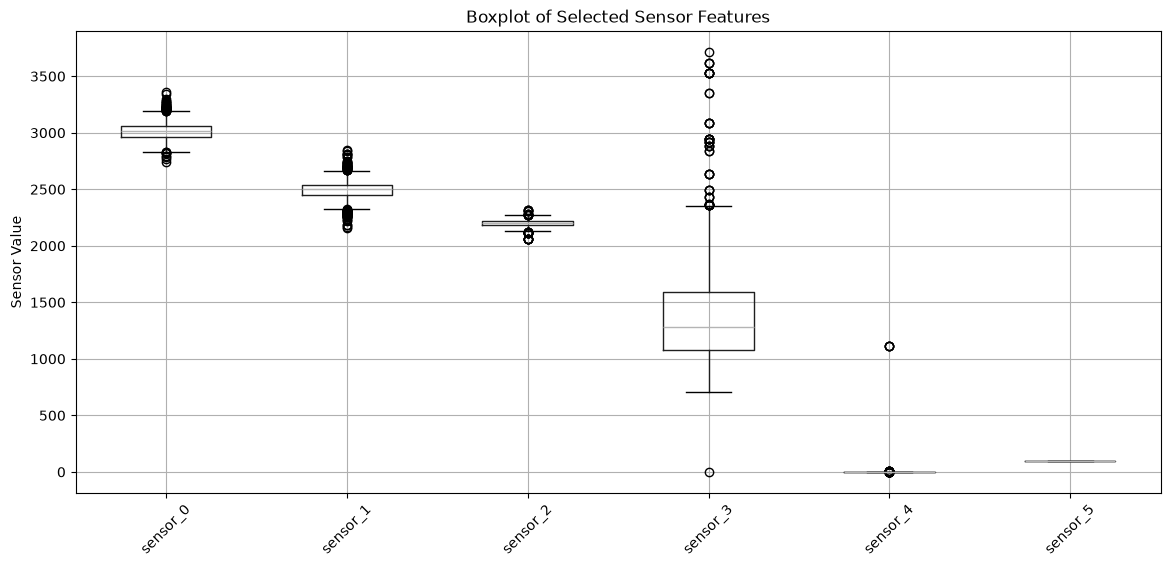

In [24]:
plt.figure(figsize=(14, 6))

df_clean[selected_sensors].boxplot()

plt.title("Boxplot of Selected Sensor Features")
plt.xticks(rotation=45)
plt.ylabel("Sensor Value")

plt.show()

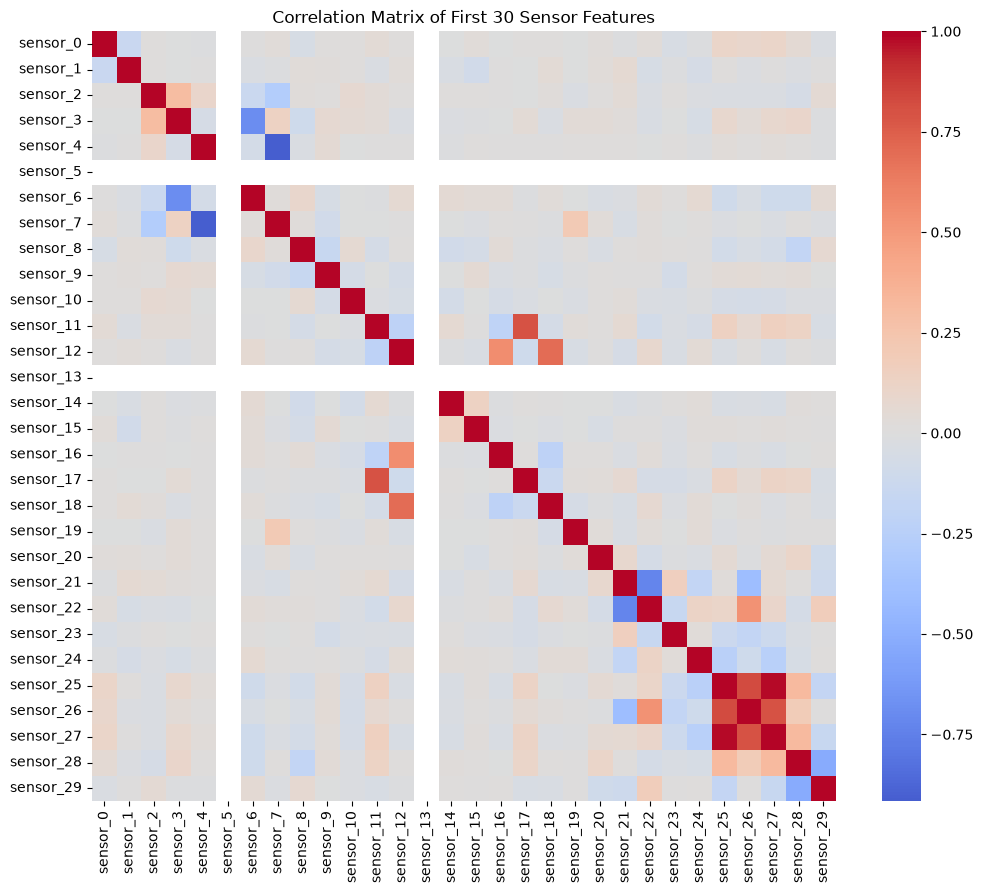

In [25]:
sensor_data_for_corr = df_clean[
    [col for col in df_clean.columns if col.startswith("sensor_")]
]

correlation_matrix = sensor_data_for_corr.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix.iloc[:30, :30],
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of First 30 Sensor Features")

plt.show()

In [26]:
feature_columns = [
    col for col in df_clean.columns
    if col.startswith("sensor_")
]

X = df_clean[feature_columns]

y = df_clean["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1567, 590)
y shape: (1567,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1253, 590)
Testing data: (314, 590)


In [28]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values in training data:",
      np.isnan(X_train_imputed).sum())

print("Missing values in testing data:",
      np.isnan(X_test_imputed).sum())

Missing values in training data: 0
Missing values in testing data: 0


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Training data standardized successfully!")
print("Testing data standardized successfully!")

Training data standardized successfully!
Testing data standardized successfully!


In [30]:
print("Training mean:",
      np.mean(X_train_scaled))

print("Training standard deviation:",
      np.std(X_train_scaled))

print("\nTesting mean:",
      np.mean(X_test_scaled))

print("Testing standard deviation:",
      np.std(X_test_scaled))

Training mean: 7.064506777873722e-17
Training standard deviation: 0.896320160717405

Testing mean: -0.000902673633855517
Testing standard deviation: 0.8582240123412774


In [31]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [32]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
target
-1    1170
 1      83
Name: count, dtype: int64

After SMOTE:
target
-1    1170
 1    1170
Name: count, dtype: int64


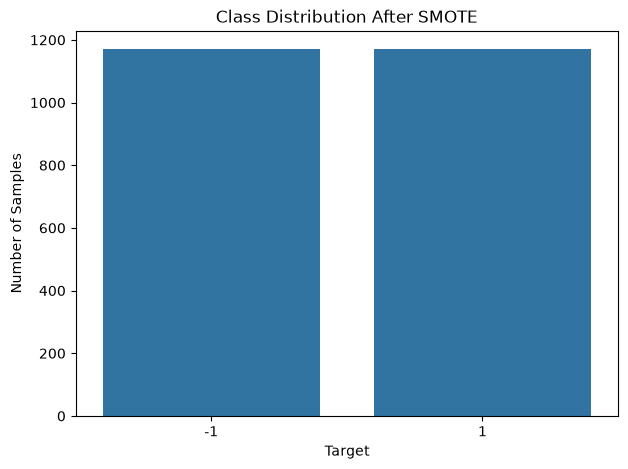

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Target")
plt.ylabel("Number of Samples")

plt.show()

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_smote, y_train_smote)

logistic_train_pred = logistic_model.predict(X_train_smote)
logistic_test_pred = logistic_model.predict(X_test_scaled)

logistic_train_accuracy = accuracy_score(
    y_train_smote,
    logistic_train_pred
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_test_pred
)

print("Logistic Regression")
print("Training Accuracy:", logistic_train_accuracy)
print("Testing Accuracy:", logistic_test_accuracy)

Logistic Regression
Training Accuracy: 0.9965811965811966
Testing Accuracy: 0.8471337579617835


In [35]:
print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        logistic_test_pred
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.89      0.92       293
           1       0.11      0.19      0.14        21

    accuracy                           0.85       314
   macro avg       0.53      0.54      0.53       314
weighted avg       0.88      0.85      0.86       314



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_train_pred = rf_model.predict(X_train_smote)
rf_test_pred = rf_model.predict(X_test_scaled)

rf_train_accuracy = accuracy_score(
    y_train_smote,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

print("Random Forest")
print("Training Accuracy:", rf_train_accuracy)
print("Testing Accuracy:", rf_test_accuracy)

Random Forest
Training Accuracy: 1.0
Testing Accuracy: 0.9331210191082803


In [37]:
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_test_pred
    )
)

Random Forest Classification Report:


C:\Users\jhana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

          -1       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



C:\Users\jhana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jhana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

svm_train_pred = svm_model.predict(X_train_smote)
svm_test_pred = svm_model.predict(X_test_scaled)

svm_train_accuracy = accuracy_score(
    y_train_smote,
    svm_train_pred
)

svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_pred
)

print("SVM")
print("Training Accuracy:", svm_train_accuracy)
print("Testing Accuracy:", svm_test_accuracy)

SVM
Training Accuracy: 0.9995726495726496
Testing Accuracy: 0.9363057324840764


In [39]:
print("SVM Classification Report:")

print(
    classification_report(
        y_test,
        svm_test_pred
    )
)

SVM Classification Report:
              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314



In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Training Accuracy": [
        logistic_train_accuracy,
        rf_train_accuracy,
        svm_train_accuracy
    ],
    "Testing Accuracy": [
        logistic_test_accuracy,
        rf_test_accuracy,
        svm_test_accuracy
    ]
})

display(model_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.996581,0.847134
1,Random Forest,1.000000,0.933121
2,SVM,0.999573,0.936306


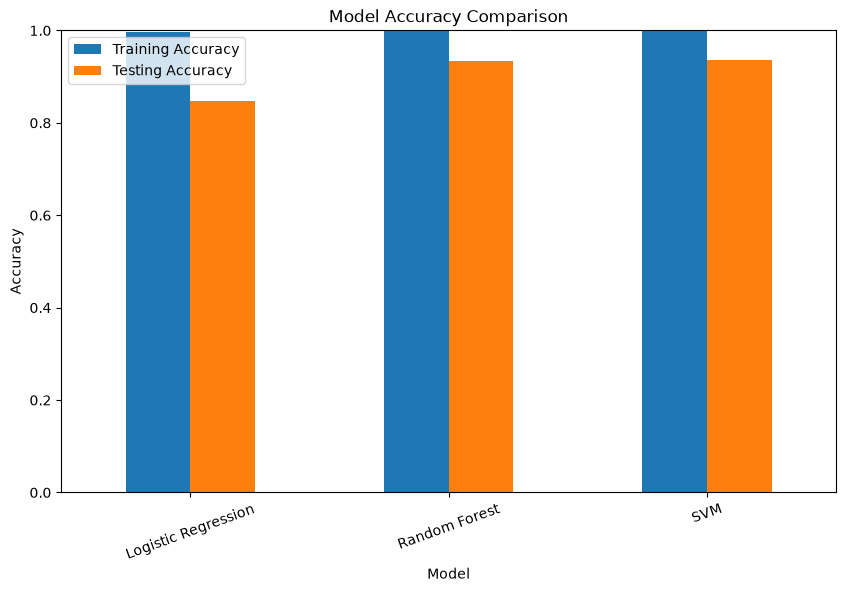

In [41]:
model_comparison.plot(
    x="Model",
    y=["Training Accuracy", "Testing Accuracy"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

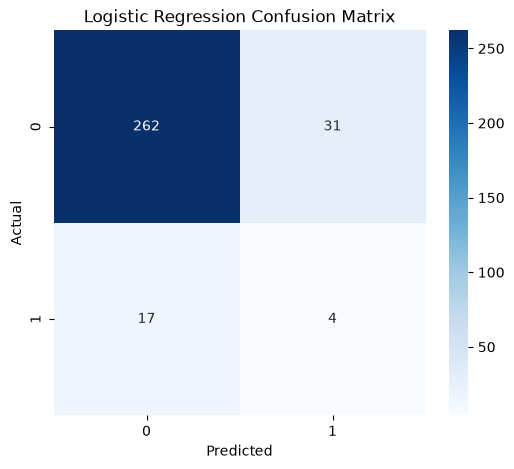

In [42]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

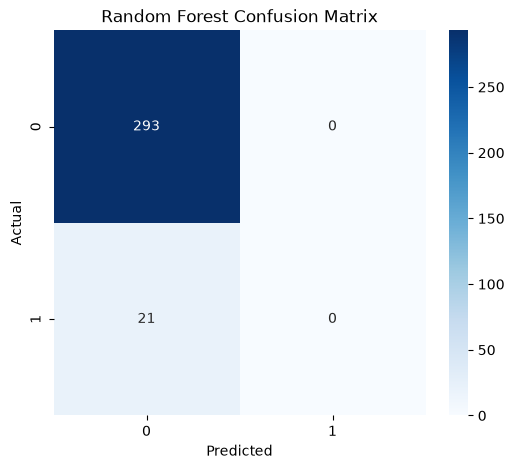

In [43]:
cm_rf = confusion_matrix(
    y_test,
    rf_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

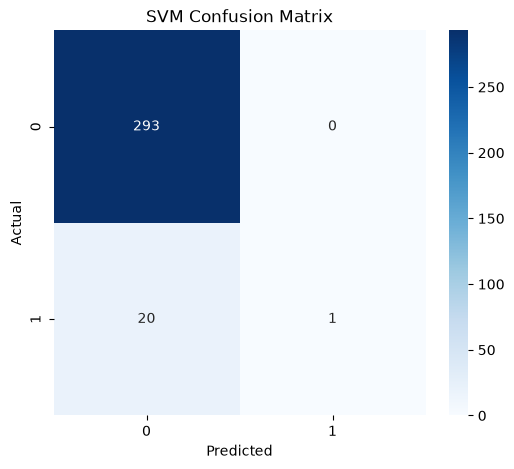

In [44]:
cm_svm = confusion_matrix(
    y_test,
    svm_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
from sklearn.model_selection import cross_val_score

cv_logistic = cross_val_score(
    logistic_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

cv_rf = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

cv_svm = cross_val_score(
    svm_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Logistic Regression CV Mean:",
      cv_logistic.mean())

print("Random Forest CV Mean:",
      cv_rf.mean())

print("SVM CV Mean:",
      cv_svm.mean())

Logistic Regression CV Mean: 0.9397435897435896
Random Forest CV Mean: 0.9931623931623932
SVM CV Mean: 0.9948717948717949


In [46]:
from sklearn.model_selection import GridSearchCV

logistic_params = {
    "C": [0.01, 0.1, 1, 10]
}

logistic_grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    logistic_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

logistic_grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print("Best CV Score:",
      logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 1}
Best CV Score: 0.9397435897435896


In [47]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best CV Score:",
      rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9944444444444445


In [48]:
svm_params = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best CV Score:",
      svm_grid.best_score_)

Best SVM Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9974358974358974


In [49]:
best_logistic = logistic_grid.best_estimator_

logistic_tuned_pred = best_logistic.predict(
    X_test_scaled
)

print("Tuned Logistic Regression Accuracy:",
      accuracy_score(y_test, logistic_tuned_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_tuned_pred
    )
)

Tuned Logistic Regression Accuracy: 0.8471337579617835

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      0.89      0.92       293
           1       0.11      0.19      0.14        21

    accuracy                           0.85       314
   macro avg       0.53      0.54      0.53       314
weighted avg       0.88      0.85      0.86       314



In [50]:
best_rf = rf_grid.best_estimator_

rf_tuned_pred = best_rf.predict(
    X_test_scaled
)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, rf_tuned_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_tuned_pred
    )
)

Tuned Random Forest Accuracy: 0.9299363057324841

Classification Report:
              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [51]:
best_svm = svm_grid.best_estimator_

svm_tuned_pred = best_svm.predict(
    X_test_scaled
)

print("Tuned SVM Accuracy:",
      accuracy_score(y_test, svm_tuned_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_tuned_pred
    )
)

Tuned SVM Accuracy: 0.9363057324840764

Classification Report:
              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       293
           1       1.00      0.05      0.09        21

    accuracy                           0.94       314
   macro avg       0.97      0.52      0.53       314
weighted avg       0.94      0.94      0.91       314



In [52]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Training Accuracy": [
        accuracy_score(
            y_train_smote,
            best_logistic.predict(X_train_smote)
        ),
        accuracy_score(
            y_train_smote,
            best_rf.predict(X_train_smote)
        ),
        accuracy_score(
            y_train_smote,
            best_svm.predict(X_train_smote)
        )
    ],
    "Testing Accuracy": [
        accuracy_score(
            y_test,
            logistic_tuned_pred
        ),
        accuracy_score(
            y_test,
            rf_tuned_pred
        ),
        accuracy_score(
            y_test,
            svm_tuned_pred
        )
    ],
    "CV Accuracy": [
        logistic_grid.best_score_,
        rf_grid.best_score_,
        svm_grid.best_score_
    ]
})

display(final_comparison)

,Model,Training Accuracy,Testing Accuracy,CV Accuracy
0,Logistic Regression,0.996581,0.847134,0.939744
1,Random Forest,1.000000,0.929936,0.994444
2,SVM,1.000000,0.936306,0.997436


In [53]:
best_model_name = final_comparison.loc[
    final_comparison["Testing Accuracy"].idxmax(),
    "Model"
]

print("Model with highest testing accuracy:")
print(best_model_name)

Model with highest testing accuracy:
SVM


In [54]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
486,sensor_486,0.019340
351,sensor_351,0.017313
213,sensor_213,0.014815
519,sensor_519,0.012979
377,sensor_377,0.011895
103,sensor_103,0.011238
433,sensor_433,0.011127
559,sensor_559,0.011082
33,sensor_33,0.010637
345,sensor_345,0.010482


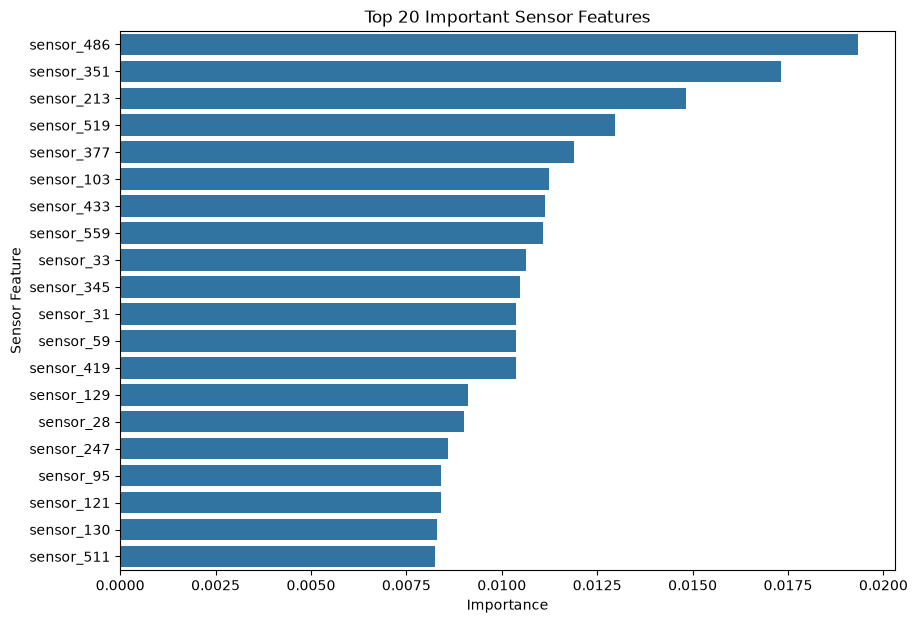

In [55]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Sensor Features")
plt.xlabel("Importance")
plt.ylabel("Sensor Feature")

plt.show()

In [56]:
top_n = 50

selected_features = feature_importance.head(
    top_n
)["Feature"].tolist()

print("Number of selected features:", len(selected_features))
print("\nSelected features:")
print(selected_features)

Number of selected features: 50

Selected features:
['sensor_486', 'sensor_351', 'sensor_213', 'sensor_519', 'sensor_377', 'sensor_103', 'sensor_433', 'sensor_559', 'sensor_33', 'sensor_345', 'sensor_31', 'sensor_59', 'sensor_419', 'sensor_129', 'sensor_28', 'sensor_247', 'sensor_95', 'sensor_121', 'sensor_130', 'sensor_511', 'sensor_561', 'sensor_112', 'sensor_197', 'sensor_477', 'sensor_308', 'sensor_563', 'sensor_560', 'sensor_146', 'sensor_155', 'sensor_290', 'sensor_346', 'sensor_124', 'sensor_510', 'sensor_500', 'sensor_489', 'sensor_469', 'sensor_417', 'sensor_547', 'sensor_205', 'sensor_91', 'sensor_336', 'sensor_183', 'sensor_392', 'sensor_430', 'sensor_385', 'sensor_200', 'sensor_297', 'sensor_64', 'sensor_452', 'sensor_281']


In [57]:
X_reduced = df_clean[selected_features]

print("Original feature count:",
      len(feature_columns))

print("Reduced feature count:",
      len(selected_features))

print("Reduced dataset shape:",
      X_reduced.shape)

Original feature count: 590
Reduced feature count: 50
Reduced dataset shape: (1567, 50)


In [58]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

reduced_imputer = SimpleImputer(strategy="median")

Xr_train = reduced_imputer.fit_transform(Xr_train)
Xr_test = reduced_imputer.transform(Xr_test)

reduced_scaler = StandardScaler()

Xr_train = reduced_scaler.fit_transform(Xr_train)
Xr_test = reduced_scaler.transform(Xr_test)

reduced_smote = SMOTE(random_state=42)

Xr_train_smote, yr_train_smote = reduced_smote.fit_resample(
    Xr_train,
    yr_train
)

print("Reduced training shape:",
      Xr_train_smote.shape)

print("Reduced testing shape:",
      Xr_test.shape)

Reduced training shape: (2340, 50)
Reduced testing shape: (314, 50)


In [59]:
reduced_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

reduced_rf.fit(
    Xr_train_smote,
    yr_train_smote
)

reduced_rf_pred = reduced_rf.predict(
    Xr_test
)

reduced_rf_accuracy = accuracy_score(
    yr_test,
    reduced_rf_pred
)

print(
    "Random Forest Accuracy with Top 50 Features:",
    reduced_rf_accuracy
)

Random Forest Accuracy with Top 50 Features: 0.9140127388535032


In [60]:
full_rf_accuracy = accuracy_score(
    y_test,
    rf_tuned_pred
)

feature_comparison = pd.DataFrame({
    "Approach": [
        "All Available Features",
        "Top 50 Features"
    ],
    "Number of Features": [
        len(feature_columns),
        len(selected_features)
    ],
    "Testing Accuracy": [
        full_rf_accuracy,
        reduced_rf_accuracy
    ]
})

display(feature_comparison)

,Approach,Number of Features,Testing Accuracy
0,All Available Features,590,0.929936
1,Top 50 Features,50,0.914013


In [61]:
import joblib

final_model = best_rf

model_package = {
    "model": final_model,
    "imputer": imputer,
    "scaler": scaler,
    "feature_columns": feature_columns
}

joblib.dump(
    model_package,
    "semiconductor_yield_best_model.joblib"
)

print("Final model saved successfully!")

Final model saved successfully!


In [62]:
loaded_package = joblib.load(
    "semiconductor_yield_best_model.joblib"
)

loaded_model = loaded_package["model"]
loaded_imputer = loaded_package["imputer"]
loaded_scaler = loaded_package["scaler"]
loaded_features = loaded_package["feature_columns"]

print("Model loaded successfully!")

print("Number of stored features:",
      len(loaded_features))

Model loaded successfully!
Number of stored features: 590


In [63]:
loaded_prediction = loaded_model.predict(
    X_test_scaled
)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_prediction
)

print("Accuracy of loaded model:",
      loaded_accuracy)

Accuracy of loaded model: 0.9299363057324841


In [64]:
print("FINAL MODEL:", best_model_name)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        loaded_prediction
    )
)

FINAL MODEL: SVM

Final Classification Report:
              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



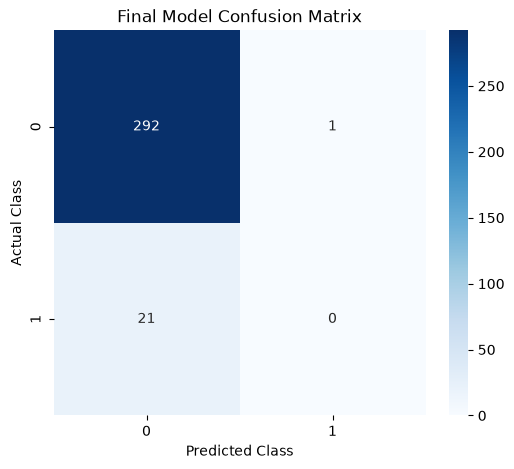

In [65]:
final_cm = confusion_matrix(
    y_test,
    loaded_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [66]:
print("=" * 60)
print("SEMICONDUCTOR MANUFACTURING YIELD PREDICTION")
print("=" * 60)

print("\nDataset Shape:", df_clean.shape)

print("Original Sensor Features:",
      len(feature_columns))

print("Reduced Features:",
      len(selected_features))

print("\nModel Comparison:")
display(final_comparison)

print("\nFeature Reduction Comparison:")
display(feature_comparison)

print("\nFinal Model:",
      best_model_name)

print("\nFinal Test Accuracy:",
      loaded_accuracy)

print("\nModel file:")
print("semiconductor_yield_best_model.joblib")

SEMICONDUCTOR MANUFACTURING YIELD PREDICTION

Dataset Shape: (1567, 592)
Original Sensor Features: 590
Reduced Features: 50

Model Comparison:


,Model,Training Accuracy,Testing Accuracy,CV Accuracy
0,Logistic Regression,0.996581,0.847134,0.939744
1,Random Forest,1.000000,0.929936,0.994444
2,SVM,1.000000,0.936306,0.997436



Feature Reduction Comparison:


,Approach,Number of Features,Testing Accuracy
0,All Available Features,590,0.929936
1,Top 50 Features,50,0.914013



Final Model: SVM

Final Test Accuracy: 0.9299363057324841

Model file:
semiconductor_yield_best_model.joblib


In [69]:
print("""
CONCLUSION

1. The semiconductor manufacturing dataset was explored and cleaned.
2. Missing values were handled using median imputation.
3. Constant features were identified and removed.
4. Exploratory data analysis was performed using statistical analysis,
   distributions, boxplots and correlation analysis.
5. The dataset was divided into training and testing sets.
6. Standardization was applied to the numerical sensor features.
7. SMOTE was applied to the training data to address class imbalance.
8. Logistic Regression, Random Forest and SVM classifiers were trained.
9. Cross-validation and GridSearchCV were used for model tuning.
10. Model performance was compared using training accuracy,
    testing accuracy and classification reports.
11. Feature importance was analyzed to identify important sensor signals.
12. A reduced feature set was also tested to investigate whether all
    sensor features are necessary.
13. The selected final model was saved as
    semiconductor_yield_best_model.joblib.
""")


CONCLUSION

1. The semiconductor manufacturing dataset was explored and cleaned.
2. Missing values were handled using median imputation.
3. Constant features were identified and removed.
4. Exploratory data analysis was performed using statistical analysis,
   distributions, boxplots and correlation analysis.
5. The dataset was divided into training and testing sets.
6. Standardization was applied to the numerical sensor features.
7. SMOTE was applied to the training data to address class imbalance.
8. Logistic Regression, Random Forest and SVM classifiers were trained.
9. Cross-validation and GridSearchCV were used for model tuning.
10. Model performance was compared using training accuracy,
    testing accuracy and classification reports.
11. Feature importance was analyzed to identify important sensor signals.
12. A reduced feature set was also tested to investigate whether all
    sensor features are necessary.
13. The selected final model was saved as
    semiconductor_yield_best

# 15. Conclusion

The semiconductor manufacturing dataset was successfully analyzed and used
to develop machine learning models for Pass/Fail prediction.

The dataset was cleaned by handling missing values and removing constant
features. Exploratory data analysis was performed to understand the sensor
measurements and target distribution.

Three supervised machine learning algorithms were evaluated: Logistic
Regression, Random Forest and Support Vector Machine (SVM). The models were
evaluated using training accuracy, testing accuracy, classification reports
and cross-validation.

SMOTE was applied to the training dataset to address class imbalance.
GridSearchCV was used for hyperparameter tuning.

Feature importance analysis was performed to identify important sensor
features. A reduced feature set was also evaluated to investigate whether
all available features are necessary.

The final model was saved as
`semiconductor_yield_best_model.joblib` for future use.

In [ ]:
s